# Road casualty time‑series — Monthly trends and law effects

## Dataset Overview

The datasets `UKDriverDeaths` and `Seatbelts` are built-in time series datasets available in R packages. The `UKDriverDeaths` dataset contains monthly totals of car drivers in Great Britain who were killed or seriously injured (KSI) over a 16-year period. This dataset is often used in conjunction with the `Seatbelts` dataset, which contains monthly data on road casualties in Great Britain from January 1969 to December 1984. For detailed attributes and dataset structures, refer to the datasets' documentation within the packages.

## Objectives

a. **Combine data:** Produce a dataframe that combines the temporal information provided in `UKDriverDeaths` with the other information in `Seatbelts`.

b. **Plot graphs:** Produce a faceted graph (using `facet_wrap()`, placing `drivers`, `front`, `rear`, and `VanKilled` in facets) showing a timeline of monthly means of deaths (means taken across years) whilst distinguishing between the two levels of `law`.

c. **Conclusion:** What do you conclude from your analysis?


Before we begin with the analyses, I first want to prevent warning messages from appearing on my code block. *This method can be ignored when you are using RStudio or base R to do your coding. I am only using it because I am using an R kernel in Jupyter Notebook.*

In [3]:
options(warn = 1)

# Set to 0 to enable warnings
# Set to 1 to remove warnings

### **a. Combining data**

First and foremost, we have to install the **tidyverse**, which is a collection of packages designed to make common data tasks like data cleaning, manipulation, and visualisation more intuitive and efficient compared to base R:

In [ ]:
install.packages("tidyverse")

A noticable difference from the previous activities is that we did not have to install the `UKDriverDeaths` and `Seatbelts` packages. This is because these packages are built directly into R and are not stored into other packages just as the mercury data in the **coin** package. In order to access `UKDriverDeaths` and `Seatbelts`, we type:

In [4]:
# Load tidyverse package

library(tidyverse)

# Load UKDriverDeaths and Seatbelts datasets

deaths <- datasets::UKDriverDeaths
seatbelts <- datasets::Seatbelts

After loading the datasets and assigning them their names, we can view the data to see how it is structure (This part is not necessary).

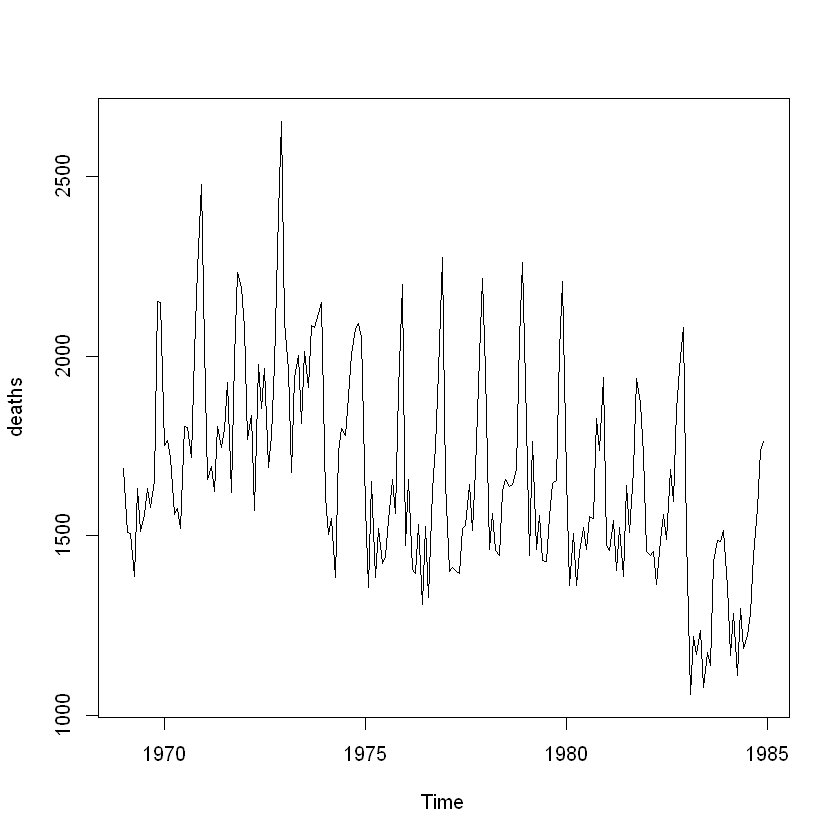

In [6]:
plot(deaths)

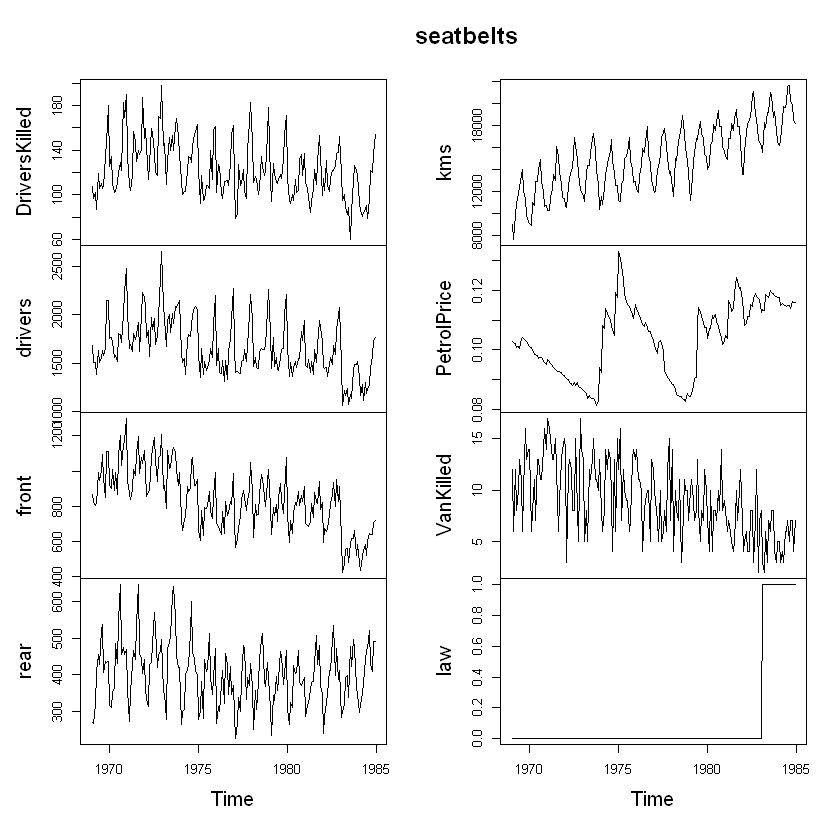

In [7]:
plot(seatbelts)

In [8]:
# Make the combined dataframe
df <- data.frame(date = seq.Date(as.Date("1969-01-01"), as.Date("1984-12-01"), by = "month"),
                 as.matrix(seatbelts))

### **b. Plot graph**

The datasets have now been merged by their months. From here onwards we tidy the data for plotting by using the `pivot_longer` function from tidyverse to structure our data in a long format, and then plot the data using `ggplot`.

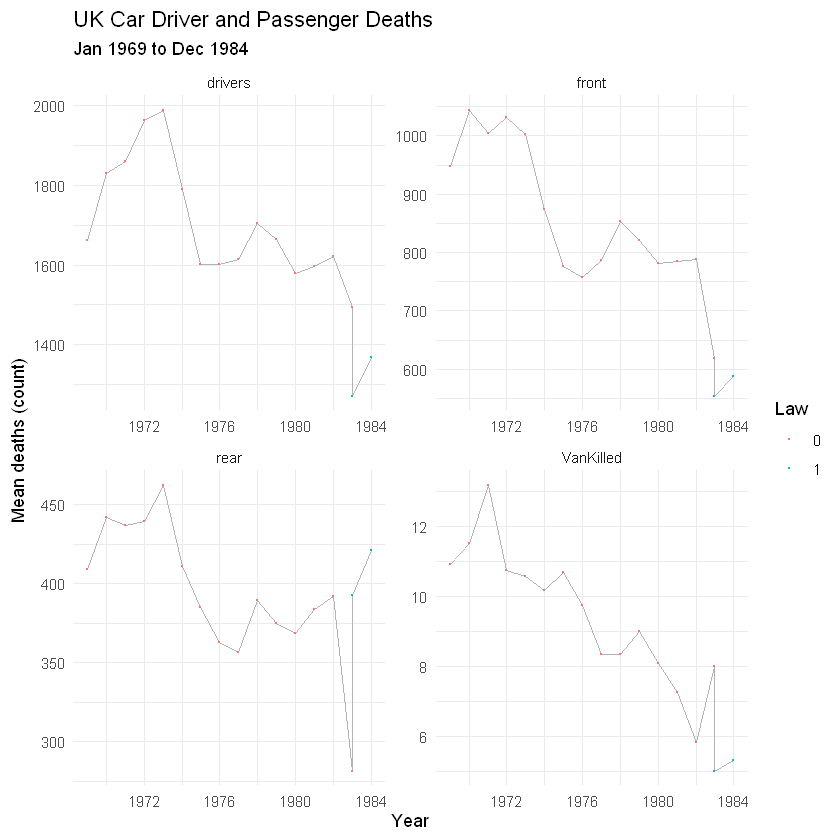

In [9]:
# make long dataframe
df |>
  select(-DriversKilled, -kms, -PetrolPrice) |>
  pivot_longer(cols = c(drivers, front, rear, VanKilled),
               names_to = "type",
               values_to = "killed") |>
  mutate(year = year(date)) |>
  group_by(year, type, law) |>
  summarise(mean_killed = round(mean(killed), 2), .groups = "drop") |>
  ggplot(aes(x = year, y = mean_killed)) +
    geom_line(colour = "grey70") +
    geom_point(aes(colour = as.factor(law)), size = 0.3) +
    facet_wrap(~type, ncol = 2, scales = "free") +
    guides(colour = guide_legend("Law")) +
    theme_minimal() +
    labs(x = "Year", y = "Mean deaths (count)",
         title = "UK Car Driver and Passenger Deaths",
         subtitle = "Jan 1969 to Dec 1984")

The data indicate that mandatory the seatbelt law, introduced on January 31, 1983, appears to have reduced the number of deaths resulting from car crashes for drivers and front passengers of passenger cars, and for the drivers of vans. However, there was no apparent reduction in deaths for rear passengers, likely because the law requiring them to wear seatbelts did not come into effect until 1991.

It should be noted, however, that the interpretation of these results is not entirely clear. From 1969 to December 1982, there was a consistent reduction in deaths, which may have been due to other advancements in car safety features and road safety legislation. Additionally, only two data points are available following the introduction of mandatory seatbelt laws in 1983, and more data are needed to determine whether this reduction was statistically significant. Nevertheless, it is worth noting that the reduction did prove to be statistically significant.